<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_10_Implementation_Of_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch: 0
Epoch: 100
Epoch: 200
Epoch: 300
Epoch: 400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


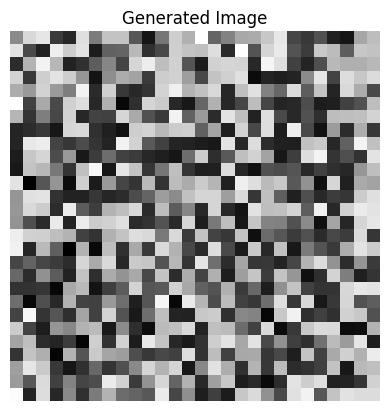

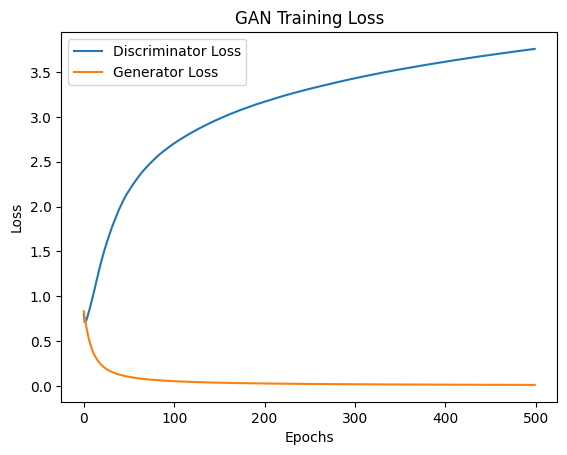

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape

(X_train, _), (_, _) = mnist.load_data()

X_train = X_train / 255.0
X_train = X_train.reshape(X_train.shape[0], 784)

generator = Sequential([
    Dense(128, input_dim=100),
    LeakyReLU(0.2),
    Dense(784, activation='sigmoid'),
    Reshape((784,))
])

discriminator = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(0.2),
    Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

epochs = 500
batch_size = 32

d_losses = []
g_losses = []

for epoch in range(epochs):

    idx = np.random.randint(0, X_train.shape[0], batch_size)

    real_images = X_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))

    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(
        real_images,
        np.ones((batch_size, 1))
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        np.zeros((batch_size, 1))
    )

    noise = np.random.normal(0, 1, (batch_size, 100))

    g_loss = gan.train_on_batch(
        noise,
        np.ones((batch_size, 1))
    )

    d_losses.append(d_loss_real[0])
    g_losses.append(g_loss)

    if epoch % 100 == 0:
        print("Epoch:", epoch)

noise = np.random.normal(0, 1, (1, 100))

generated_image = generator.predict(noise)

generated_image = generated_image.reshape(28, 28)

plt.imshow(generated_image, cmap='gray')
plt.title("Generated Image")
plt.axis('off')
plt.show()

plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')

plt.title("GAN Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()